In [56]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

In [57]:
df = pd.read_excel("../data/austinHousing.xlsx")

In [58]:
#view dataset
df.head

#dataset structure
df.info

#statistical summary
df.describe(include='all')

,house_ID,city,property_tax_rate,garage_spaces,has_association,has_cooling,has_garage,has_heating,has_spa,has_view,...,bathrooms,bedrooms,stories,price_changes,latest_sale_date,latest_sale_month,latest_sale_year,latest_price_source,num_photos,sale_price
count,15171.000000,15171,15171.000000,15171.000000,15171,15171,15171,15171,15171,15171,...,15171.000000,15171.000000,15171.000000,15171.000000,15171,15171.000000,15171.000000,15171,15171.000000,1.517100e+04
unique,NaN,9,NaN,NaN,2,2,2,2,2,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225,NaN,NaN
top,NaN,austin,NaN,NaN,yes,yes,yes,yes,no,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Agent Provided,NaN,NaN
freq,NaN,15020,NaN,NaN,8007,14897,8346,15022,13972,11705,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10486,NaN,NaN
mean,8586.000000,NaN,1.994085,1.229187,NaN,NaN,NaN,NaN,NaN,NaN,...,2.683010,3.440841,1.467273,3.032892,2019-08-06 18:01:58.172829,6.733043,2019.078241,NaN,30.640432,5.127677e+05
min,1001.000000,NaN,1.980000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,1.000000,1.000000,2018-01-22 00:00:00,1.000000,2018.000000,NaN,1.000000,5.500000e+03
25%,4793.500000,NaN,1.980000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,3.000000,1.000000,1.000000,2018-11-02 00:00:00,4.000000,2018.000000,NaN,20.000000,3.090000e+05
50%,8586.000000,NaN,1.980000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,3.000000,1.000000,2.000000,2019-08-01 00:00:00,7.000000,2019.000000,NaN,29.000000,4.050000e+05
75%,12378.500000,NaN,1.980000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,4.000000,2.000000,4.000000,2020-05-28 12:00:00,9.000000,2020.000000,NaN,39.000000,5.750000e+05
max,16171.000000,NaN,2.210000,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,27.000000,20.000000,4.000000,23.000000,2021-01-30 00:00:00,12.000000,2021.000000,NaN,179.000000,1.350000e+07


In [59]:
# Check missing values
df.isna().sum()
#check missing values in columns
df.isna().values.any()
#check missing values in rows
df.isna().any(axis=1).any()


np.False_

In [60]:
#check missing values in specific column
df['latest_price_source'].isna

#show all rows with missing values
missing_rowcount = df.isna().any(axis = 1).sum()
print("Rows with missing values:", missing_rowcount )

Rows with missing values: 0


In [61]:
#identify duplicated data
df.duplicated().any()

np.False_

In [62]:
# List of columns to convert to categorical
cols_to_category = [
    "city", "house_type", "has_association", "has_cooling",
    "has_garage", "has_heating", "has_spa", "has_view",
    "parking_features", "patio_porch_features", "security_features",
    "waterfront_features", "window_features", "community_features",
    "primary_schools", "elementary_schools", "middle_schools",
    "high_schools", "school_rating", "stories",
    "latest_sale_month", "latest_price_source", "latest_sale_year"]

df[cols_to_category] = df[cols_to_category].astype("category")

In [63]:
# Select only numerical columns from the dataset
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove identifier columns (e.g., sale_id) 
# because they are unique IDs and do not carry analytical meaning
if "house_ID" in num_cols:
    num_cols.remove("house_ID")

# Print the final list of numerical columns used for analysis
print("Numerical columns (excluding ID columns):")
print(num_cols)

Numerical columns (excluding ID columns):
['property_tax_rate', 'garage_spaces', 'parking_spaces', 'year_built', 'accessibility_features', 'appliances', 'lot_area', 'living_area', 'school_dist', 'school_size', 'student_teacher', 'bathrooms', 'bedrooms', 'price_changes', 'num_photos', 'sale_price']


In [64]:
# Define a function to identify outliers using the IQR method
def count_outliers_iqr(data, columns):
    outlier_summary = []

    # Loop through each numerical column
    for col in columns:
        # Calculate Q1, Q3 and IQR
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define lower and upper bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count number of outliers in the column
        outlier_count = data[(data[col] < lower_bound) | (data[col] > upper_bound)].shape[0]

        # Save results in a dictionary
        outlier_summary.append({
            "column": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_count
        })

    # Convert the list of results into a DataFrame
    return pd.DataFrame(outlier_summary)

In [65]:
# Get outlier summary before handling
outlier_summary_before = count_outliers_iqr(df, num_cols)

# Sort columns by highest number of outliers
outlier_summary_before.sort_values(by="outlier_count", ascending=False)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,property_tax_rate,1.98,1.980000,0.000000,1.98,1.980000,1416
6,lot_area,6534.00,10890.000000,4356.000000,0.00,17424.000000,1316
15,sale_price,309000.00,575000.000000,266000.000000,-90000.00,974000.000000,1071
14,num_photos,20.00,39.000000,19.000000,-8.50,67.500000,967
11,bathrooms,2.00,3.000000,1.000000,0.50,4.500000,780
8,school_dist,1.10,2.266667,1.166667,-0.65,4.016667,697
13,price_changes,1.00,4.000000,3.000000,-3.50,8.500000,618
5,appliances,2.00,4.000000,2.000000,-1.00,7.000000,529
7,living_area,1483.00,2687.000000,1204.000000,-323.00,4493.000000,447
12,bedrooms,3.00,4.000000,1.000000,1.50,5.500000,306


In [66]:
# Define columns where outliers need to be handled
outlier_cols = ["sale_price", "lot_area", "bathrooms", "bedrooms"]

print("Columns selected for outlier treatment:")
print(outlier_cols)

Columns selected for outlier treatment:
['sale_price', 'lot_area', 'bathrooms', 'bedrooms']


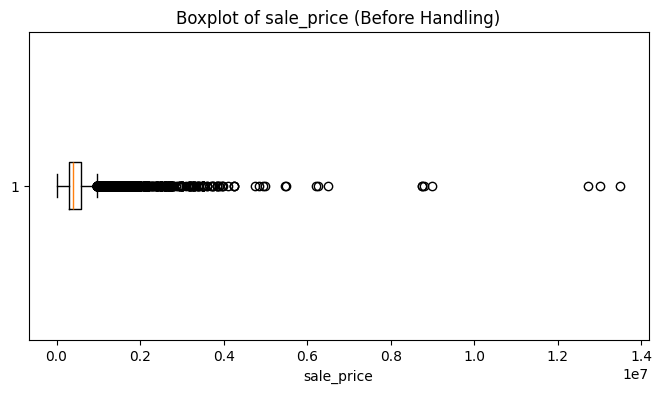

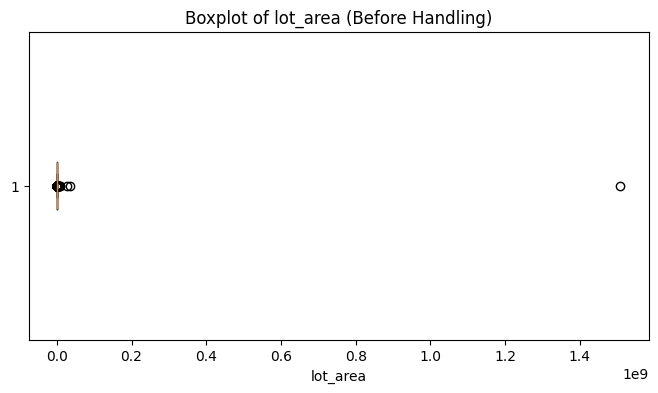

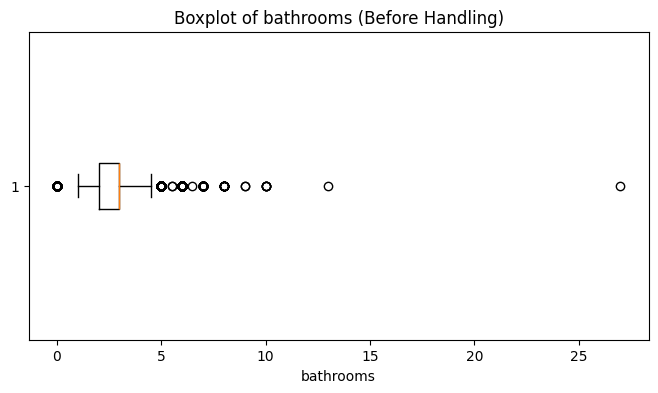

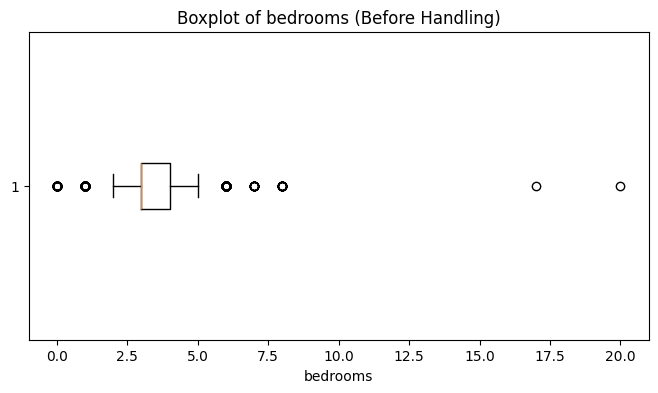

In [67]:
# Boxplots for selected columns (before handling)
for col in outlier_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col} (Before Handling)")
    plt.xlabel(col)
    plt.show()

In [68]:
# Create a copy of dataset to preserve original data
df_capped = df.copy()

# Apply IQR capping only on selected columns
for col in outlier_cols:
    
    # Calculate Q1, Q3, and IQR
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap lower outliers
    df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])

    # Cap upper outliers
    df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])

In [69]:
# Function to count outliers (reuse for selected columns)
def count_outliers_selected(data, columns):
    summary = []

    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_count = data[(data[col] < lower_bound) | (data[col] > upper_bound)].shape[0]

        summary.append({
            "column": col,
            "outlier_count": outlier_count
        })

    return pd.DataFrame(summary)

# Check after capping
outliers_after = count_outliers_selected(df_capped, outlier_cols)
outliers_after

,column,outlier_count
0,sale_price,0
1,lot_area,0
2,bathrooms,0
3,bedrooms,0


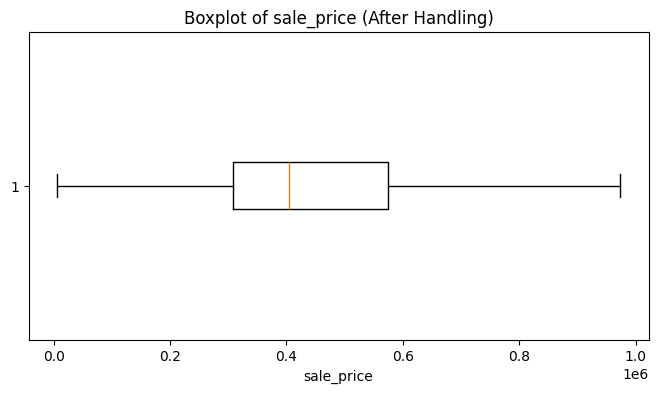

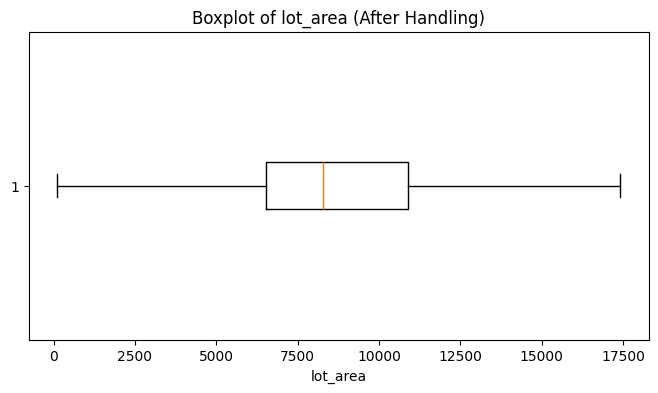

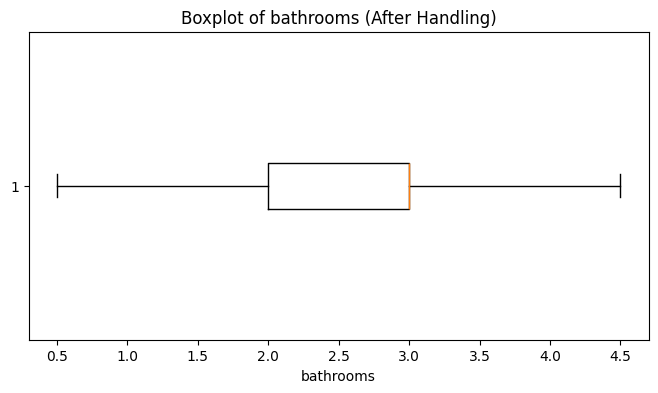

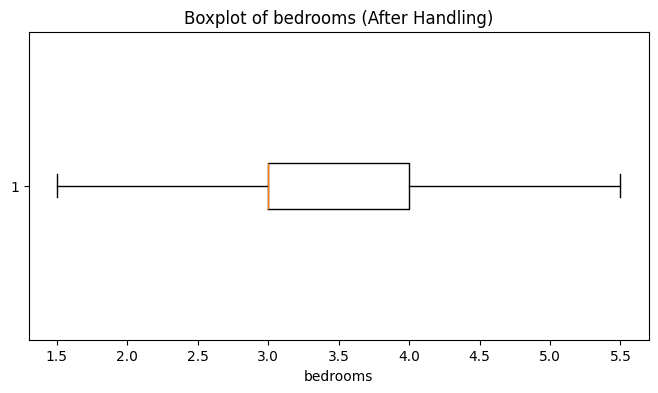

In [70]:
# Boxplots after capping
for col in outlier_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df_capped[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col} (After Handling)")
    plt.xlabel(col)
    plt.show()

In [72]:
# Get before counts (reuse earlier function if available)
outliers_before = count_outliers_selected(df, outlier_cols)

# Merge comparison
comparison = outliers_before.merge(
    outliers_after,
    on="column",
    suffixes=("_before", "_after")
)

comparison

,column,outlier_count_before,outlier_count_after
0,sale_price,1071,0
1,lot_area,1316,0
2,bathrooms,780,0
3,bedrooms,306,0


In [74]:
# Standardize values in 'has_view' column
# Replace 'y' with 'yes' and 'n' with 'no'

df['has_view'] = df['has_view'].replace({'y': 'yes', 'n': 'no'})

# Check unique values after recoding (equivalent to levels in R)
print(df['has_view'].unique())

['no', 'yes']
Categories (4, str): ['n', 'no', 'y', 'yes']


In [76]:
# Round 'bathrooms' column to nearest whole number

df['bathrooms'] = df['bathrooms'].round()

# Display updated values
print(df['bathrooms'])

0        3.0
1        2.0
2        2.0
3        2.0
4        3.0
        ... 
15166    2.0
15167    4.0
15168    3.0
15169    2.0
15170    1.0
Name: bathrooms, Length: 15171, dtype: float64


In [78]:
# Round 'school_rating' column to nearest whole number

df['school_rating'] = df['school_rating'].round()

# Display updated values
print(df['school_rating'])

0        2.666667
1        2.666667
2        3.000000
3        2.666667
4        4.000000
           ...   
15166    3.333333
15167    6.666667
15168    5.000000
15169    6.666667
15170    6.666667
Name: school_rating, Length: 15171, dtype: category
Categories (27, float64): [2.333333, 2.666667, 3.000000, 3.333333, ..., 8.666667, 9.000000, 9.333333, 9.500000]


In [80]:
# Convert to integer after rounding
df['bathrooms'] = df['bathrooms'].round().astype('Int64')
df['school_rating'] = df['school_rating'].round().astype('Int64')

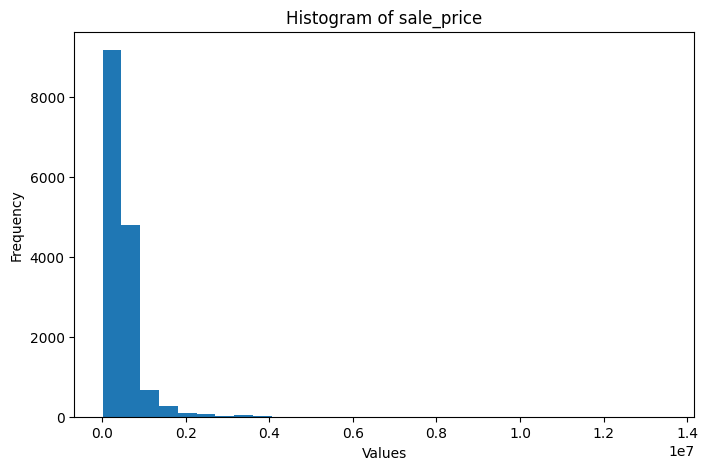

In [82]:
# Plot histogram for sale_price

plt.figure(figsize=(8, 5))
plt.hist(df['sale_price'].dropna(), bins=30)

plt.title("Histogram of sale_price")
plt.xlabel("Values")
plt.ylabel("Frequency")

plt.show()

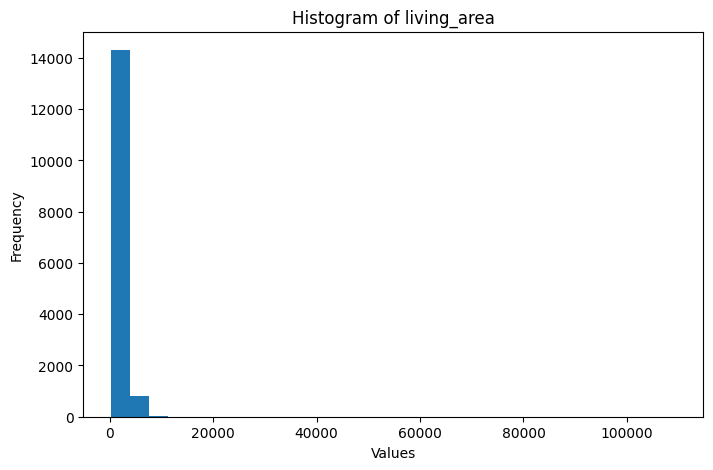

In [84]:
# Plot histogram for living_area

plt.figure(figsize=(8, 5))
plt.hist(df['living_area'].dropna(), bins=30)

plt.title("Histogram of living_area")
plt.xlabel("Values")
plt.ylabel("Frequency")

plt.show()

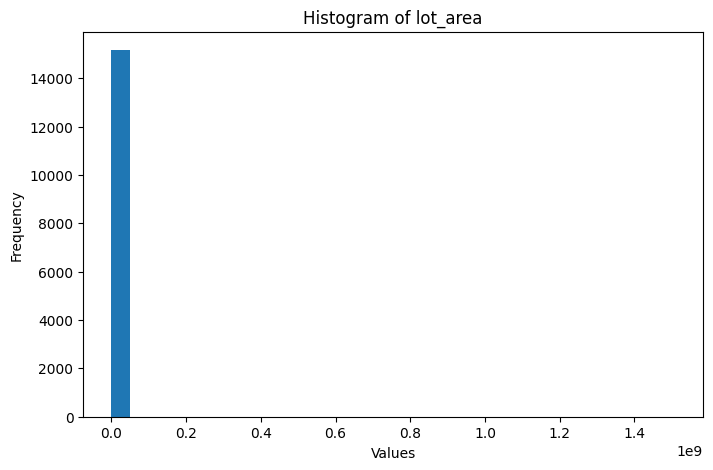

In [86]:
# Plot histogram for lot_area

plt.figure(figsize=(8, 5))
plt.hist(df['lot_area'].dropna(), bins=30)

plt.title("Histogram of lot_area")
plt.xlabel("Values")
plt.ylabel("Frequency")

plt.show()

In [88]:
# Apply log transformation only to target variable
df['sale_price_log'] = np.log1p(df['sale_price'])

In [90]:
# Import libraries for modelling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [92]:
# Target variable (log-transformed)
y = df['sale_price_log']

# Drop original target and ID columns
X = df.drop(columns=['sale_price', 'sale_price_log', 'sale_id'], errors='ignore')

In [94]:
# Convert categorical variables into dummy/indicator variables
X = pd.get_dummies(X, drop_first=True)

In [96]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [98]:
# Function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test):
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    results = {
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred))
    }
    
    return results

In [100]:
# Select a few basic features
features_model1 = ['bedrooms', 'bathrooms', 'living_area']

X_train_m1 = X_train[features_model1]
X_test_m1 = X_test[features_model1]

# Train model
model1 = LinearRegression()
model1.fit(X_train_m1, y_train)

# Evaluate
results_m1 = evaluate_model(model1, X_train_m1, X_test_m1, y_train, y_test)
results_m1

{'Train R2': 0.31750214476567096,
 'Test R2': 0.3150540354165956,
 'Train RMSE': np.float64(0.45104208054802963),
 'Test RMSE': np.float64(0.45885469371031856)}

In [102]:
# Add more relevant features
features_model2 = features_model1 + ['lot_area', 'year_built']

X_train_m2 = X_train[features_model2]
X_test_m2 = X_test[features_model2]

model2 = LinearRegression()
model2.fit(X_train_m2, y_train)

results_m2 = evaluate_model(model2, X_train_m2, X_test_m2, y_train, y_test)
results_m2

{'Train R2': 0.36727069977053195,
 'Test R2': 0.363324612659221,
 'Train RMSE': np.float64(0.43428556010334735),
 'Test RMSE': np.float64(0.44239076608766836)}

In [108]:
# Use all features, but keep only columns that Linear Regression can handle
X_train_m3 = X_train.select_dtypes(include=["number", "bool"]).copy()
X_test_m3 = X_test.select_dtypes(include=["number", "bool"]).copy()

# Convert True/False columns into 1/0
bool_cols = X_train_m3.select_dtypes(include="bool").columns
X_train_m3[bool_cols] = X_train_m3[bool_cols].astype(int)
X_test_m3[bool_cols] = X_test_m3[bool_cols].astype(int)

# Train the model
model3 = LinearRegression()
model3.fit(X_train_m3, y_train)

# Evaluate the model
results_m3 = evaluate_model(model3, X_train_m3, X_test_m3, y_train, y_test)
results_m3

{'Train R2': 0.5668432129697187,
 'Test R2': 0.5463648863269519,
 'Train RMSE': np.float64(0.3593262774160057),
 'Test RMSE': np.float64(0.3734223904774414)}

In [111]:
from sklearn.feature_selection import SelectKBest, f_regression

# Step 1: Keep only numeric and boolean columns
X_train_fs = X_train.select_dtypes(include=["number", "bool"]).copy()
X_test_fs = X_test.select_dtypes(include=["number", "bool"]).copy()

# Step 2: Convert boolean columns to 0/1
bool_cols = X_train_fs.select_dtypes(include="bool").columns
X_train_fs[bool_cols] = X_train_fs[bool_cols].astype(int)
X_test_fs[bool_cols] = X_test_fs[bool_cols].astype(int)

# Step 3: Apply SelectKBest
selector = SelectKBest(score_func=f_regression, k=10)

X_train_selected = selector.fit_transform(X_train_fs, y_train)
X_test_selected = selector.transform(X_test_fs)

# Step 4: Get selected feature names
selected_features = X_train_fs.columns[selector.get_support()]

print("Selected features:", selected_features)

Selected features: Index(['garage_spaces', 'living_area', 'school_rating', 'student_teacher',
       'bathrooms', 'bedrooms', 'num_photos', 'has_spa_yes',
       'elementary_schools_1', 'stories_2'],
      dtype='str')


In [115]:
# Convert selected features back to DataFrame
X_train_m4 = X_train[selected_features]
X_test_m4 = X_test[selected_features]

model4 = LinearRegression()
model4.fit(X_train_m4, y_train)

results_m4 = evaluate_model(model4, X_train_m4, X_test_m4, y_train, y_test)
results_m4

{'Train R2': 0.40718666192969744,
 'Test R2': 0.40563093332879985,
 'Train RMSE': np.float64(0.420363887419263),
 'Test RMSE': np.float64(0.4274399617785268)}

In [118]:
# Create comparison table
comparison = pd.DataFrame({
    "Model 1": results_m1,
    "Model 2": results_m2,
    "Model 3": results_m3,
    "Model 4": results_m4
})

comparison

,Model 1,Model 2,Model 3,Model 4
Train R2,0.317502,0.367271,0.566843,0.407187
Test R2,0.315054,0.363325,0.546365,0.405631
Train RMSE,0.451042,0.434286,0.359326,0.420364
Test RMSE,0.458855,0.442391,0.373422,0.427440


In [120]:
# Compare based on Test R2 and Test RMSE
print("Best model should have:")
print("- High Test R2")
print("- Low Test RMSE")

comparison

Best model should have:
- High Test R2
- Low Test RMSE


,Model 1,Model 2,Model 3,Model 4
Train R2,0.317502,0.367271,0.566843,0.407187
Test R2,0.315054,0.363325,0.546365,0.405631
Train RMSE,0.451042,0.434286,0.359326,0.420364
Test RMSE,0.458855,0.442391,0.373422,0.427440


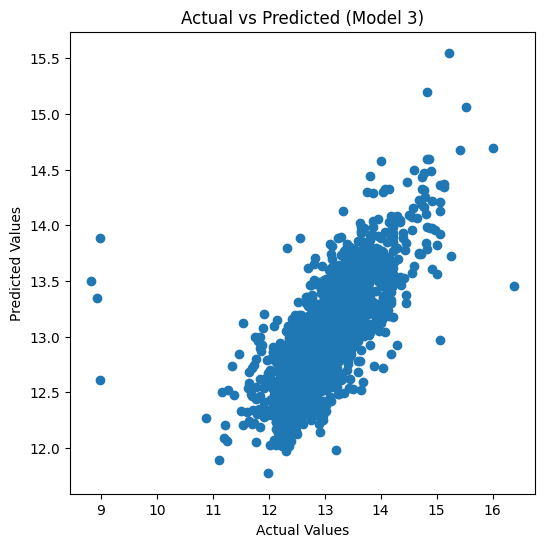

In [125]:
# Plot actual vs predicted values
import matplotlib.pyplot as plt

y_pred = model3.predict(X_test_m3)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Model 3)")
plt.show()

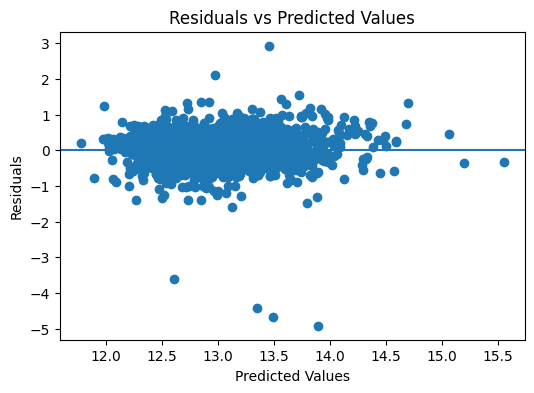

In [127]:
# Get predictions from Model 3 (or your final model)
y_pred = model3.predict(X_test_m3)

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals vs predicted values
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)  # horizontal reference line

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

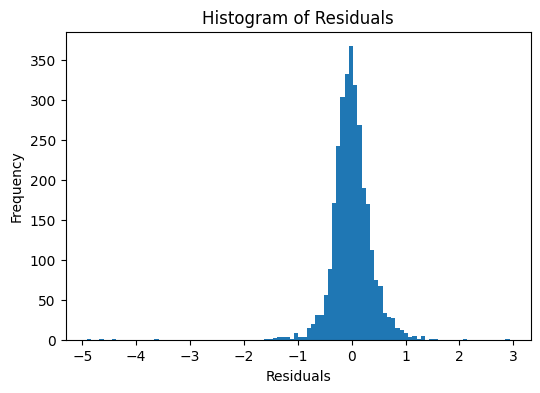

In [129]:
# Plot histogram of residuals

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=100)

plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.show()

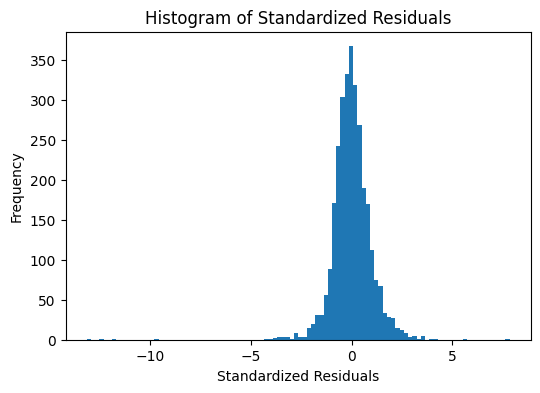

In [131]:
# Standardize residuals (Z-score)
standardized_residuals = (residuals - residuals.mean()) / residuals.std()

# Plot histogram
plt.figure(figsize=(6, 4))
plt.hist(standardized_residuals, bins=100)

plt.title("Histogram of Standardized Residuals")
plt.xlabel("Standardized Residuals")
plt.ylabel("Frequency")

plt.show()

c:\Users\Dinesh\Documents\Github Portfolio\Austin-Texas-house-price-prediction\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


count    1.207700e+04
mean     2.756000e+03
std      1.444024e+05
min      3.623430e-13
25%      7.877039e-07
50%      3.656792e-06
75%      1.453954e-05
max      1.131786e+07
dtype: float64
Max Cook's Distance: nan


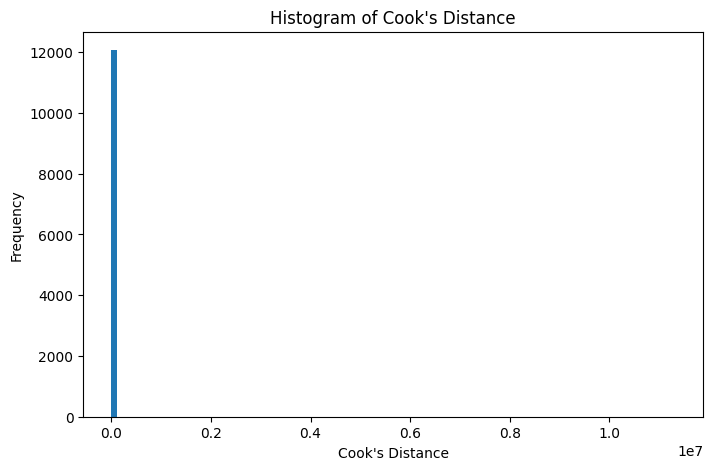

Durbin-Watson Statistic: 2.0164815675063212


In [135]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# ---------- Prepare data for OLS ----------
X_ols = X_train_m3.copy()
y_ols = y_train.copy()

# Keep only numeric + boolean columns
X_ols = X_ols.select_dtypes(include=["number", "bool"]).copy()

# Convert boolean to 0/1
bool_cols = X_ols.select_dtypes(include="bool").columns
X_ols[bool_cols] = X_ols[bool_cols].astype(int)

# Force numeric, handle inf/nan
X_ols = X_ols.apply(pd.to_numeric, errors="coerce")
y_ols = pd.to_numeric(y_ols, errors="coerce")
X_ols = X_ols.replace([np.inf, -np.inf], np.nan)
y_ols = y_ols.replace([np.inf, -np.inf], np.nan)

# Align and drop missing
data_ols = X_ols.copy()
data_ols["target"] = y_ols
data_ols = data_ols.dropna()

X_ols = data_ols.drop(columns=["target"])
y_ols = data_ols["target"]

# Add constant and ensure float dtype
X_ols = sm.add_constant(X_ols)
X_ols = X_ols.astype(float)
y_ols = y_ols.astype(float)

# ---------- Fit OLS ----------
model_ols = sm.OLS(y_ols, X_ols).fit()

# ---------- Cook's Distance ----------
influence = model_ols.get_influence()
cooks_d = influence.cooks_distance[0]

# Summary and max
print(pd.Series(cooks_d).describe())
print("Max Cook's Distance:", cooks_d.max())

# Histogram of Cook's Distance
plt.figure(figsize=(8, 5))
plt.hist(cooks_d, bins=100)
plt.title("Histogram of Cook's Distance")
plt.xlabel("Cook's Distance")
plt.ylabel("Frequency")
plt.show()

# ---------- Durbin-Watson ----------
dw_stat = durbin_watson(model_ols.resid)
print("Durbin-Watson Statistic:", dw_stat)